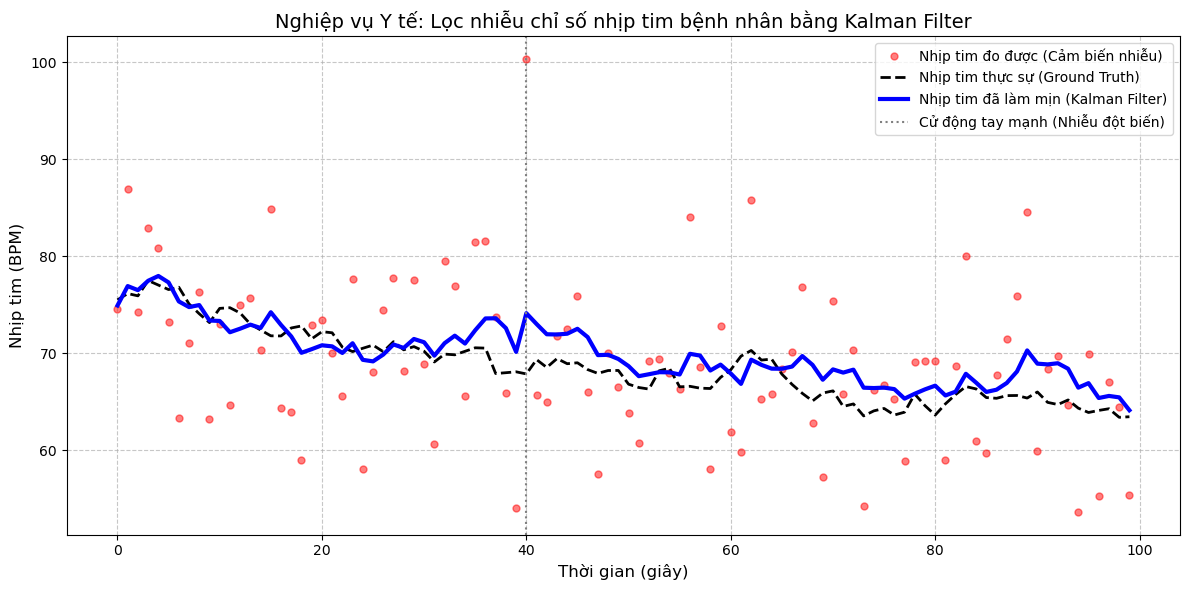

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def health_monitoring_kalman_filter():
    """
    Nghiệp vụ Y tế: Theo dõi nhịp tim bệnh nhân.
    Sử dụng Kalman Filter 1 chiều (1D) để lọc nhiễu từ thiết bị đo.
    """
    np.random.seed(42)
    n_steps = 100 # Thời gian theo dõi (ví dụ: 100 giây)

    # 1. THIẾT LẬP THÔNG SỐ (1 Chiều)
    # Nhiễu quá trình (Q): Biến thiên sinh học tự nhiên của nhịp tim (nhịp tim thường không nhảy vọt chớp nhoáng)
    Q = 1.0

    # Nhiễu cảm biến (R): Mức độ sai số của thiết bị đeo tay (Smartwatch thường xuyên bị nhiễu do cử động)
    R = 50.0

    # 2. TẠO DỮ LIỆU MÔ PHỎNG (GROUND TRUTH & MEASUREMENTS)
    true_heart_rate = 75.0 # Nhịp tim thực tế ban đầu (bpm)
    true_states = []
    measurements = []

    for _ in range(n_steps):
        # Trạng thái thực (Trạng thái ẩn): Nhịp tim thay đổi tự nhiên một chút
        true_heart_rate += np.random.normal(0, np.sqrt(Q))
        true_states.append(true_heart_rate)

        # Bằng chứng/Quan sát (Cảm biến): Bị nhiễu nặng do bệnh nhân cử động tay
        sensor_reading = true_heart_rate + np.random.normal(0, np.sqrt(R))

        # Thêm một cú sốc nhiễu lớn (outlier) ở giây thứ 40 (VD: Bệnh nhân vung tay mạnh)
        if _ == 40:
            sensor_reading += 30.0

        measurements.append(sensor_reading)

    # 3. THUẬT TOÁN KALMAN FILTER 1 CHIỀU
    # Khởi tạo niềm tin ban đầu
    mu = 75.0      # Dự đoán nhịp tim ban đầu (Mean)
    Sigma = 10.0   # Độ không chắc chắn ban đầu (Covariance)

    filtered_hr = []

    for z in measurements:
        # BƯỚC 1: DỰ ĐOÁN (PREDICT)
        # Vì nhịp tim ở trạng thái nghỉ ngơi thường ổn định, dự đoán nhịp tim tiếp theo bằng nhịp tim hiện tại
        mu_pred = mu
        Sigma_pred = Sigma + Q # Sự không chắc chắn tăng lên theo thời gian

        # BƯỚC 2: CẬP NHẬT (UPDATE)
        # Tính Kalman Gain (K) - Trọng số quyết định tin vào cảm biến hay tin vào dự đoán
        K = Sigma_pred / (Sigma_pred + R)

        # Cập nhật Trạng thái (mu) và Độ không chắc chắn (Sigma)
        mu = mu_pred + K * (z - mu_pred)
        Sigma = (1 - K) * Sigma_pred

        filtered_hr.append(mu)

    # 4. TRỰC QUAN HÓA KẾT QUẢ ĐỂ BÁC SĨ ĐÁNH GIÁ
    plt.figure(figsize=(12, 6))

    # Biểu đồ nhịp tim đo được từ cảm biến bị nhiễu
    plt.plot(measurements, 'r.', alpha=0.5, markersize=10, label='Nhịp tim đo được (Cảm biến nhiễu)')

    # Biểu đồ nhịp tim thực tế (ẩn)
    plt.plot(true_states, 'k--', linewidth=2, label='Nhịp tim thực sự (Ground Truth)')

    # Biểu đồ nhịp tim sau khi lọc qua Kalman
    plt.plot(filtered_hr, 'b-', linewidth=3, label='Nhịp tim đã làm mịn (Kalman Filter)')

    # Đánh dấu điểm nhiễu bất thường
    plt.axvline(x=40, color='gray', linestyle=':', label='Cử động tay mạnh (Nhiễu đột biến)')

    plt.title("Nghiệp vụ Y tế: Lọc nhiễu chỉ số nhịp tim bệnh nhân bằng Kalman Filter", fontsize=14)
    plt.xlabel("Thời gian (giây)", fontsize=12)
    plt.ylabel("Nhịp tim (BPM)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Thực thi
health_monitoring_kalman_filter()